# Analyse des retards de livraison

**Projet Data Science - Semaine 17 · Groupe 4**

Question traitée : **quels facteurs allongent le plus les retards de livraison,
et sur quoi peut-on agir ?**

Données : *Food Delivery Dataset* (Kaggle, `train.csv`), 45 593 livraisons
urbaines réelles, février-avril 2022.

Source : <https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset>

---

## Sommaire

| Partie | Tâches | Contenu
|---|---|---
| A - Préparer les données | 1 à 4 | Chargement, nettoyage, variables, seuil de retard
| B - Analyser par axe | 5 à 9 | Temps, Espace, Conditions, Véhicule, Coût
| C - Croiser et comparer | 10 à 12 | Corrélations, comparaisons, tableau de bord
| D - Conclure | 13 à 16 | Scénarios, règles d'interprétation, bilan


## 0. Préparation

Cellule à exécuter une seule fois, au début du notebook. Elle importe les
outils, localise le fichier de données et crée les dossiers de sortie.

In [42]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Localisation du projet -----------------------------------------------
# On remonte les niveaux jusqu'à trouver data/raw/train.csv, afin que le
# notebook fonctionne quel que soit le dossier de lancement.
dossier = Path.cwd()
while dossier != dossier.parent and not (dossier / "data" / "raw" / "train.csv").exists():
    dossier = dossier.parent

FICHIER_DONNEES = dossier / "data" / "raw" / "train.csv"
DOSSIER_FIGURES = dossier / "figures"
DOSSIER_TABLES = dossier / "outputs" / "tables"
DOSSIER_FIGURES.mkdir(parents=True, exist_ok=True)
DOSSIER_TABLES.mkdir(parents=True, exist_ok=True)

# --- Affichage -------------------------------------------------------------
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.titlesize"] = 13

SEUIL_MIN_LIVRAISONS = 100   # règle de fiabilité fixée avant l'analyse (KPI K12)

## Tâche 1 - Ingestion

Le fichier source contient **20 colonnes** : identifiants, coordonnées GPS,
horodatages, météo, trafic, véhicule et la durée de livraison.

Trois défauts ont été relevés et seront corrigés en tâche 2 :
espaces parasites autour des textes, durée stockée avec son unité
(`"(min) 24"`), et valeurs manquantes écrites en toutes lettres (`"NaN "`)
que les outils statistiques ne reconnaissent pas comme des absences.

In [43]:
df = pd.read_csv(FICHIER_DONNEES)

# Profil du fichier brut : types, valeurs manquantes, nombre de modalités.
profil_brut = pd.DataFrame({
    "type": df.dtypes,
    "modalites": df.nunique(),
    "exemple": [df[c].dropna().iloc[0] if df[c].notna().any() else None
                for c in df.columns],
})
profil_brut.index.name = "colonne"
profil_brut

,type,modalites,exemple
colonne,,,
ID,str,45593,0x4607
Delivery_person_ID,str,1320,INDORES13DEL02
Delivery_person_Age,str,23,37
Delivery_person_Ratings,str,29,4.9
Restaurant_latitude,float64,657,22.745049
Restaurant_longitude,float64,518,75.892471
Delivery_location_latitude,float64,4373,22.765049
Delivery_location_longitude,float64,4373,75.912471
Order_Date,str,44,19-03-2022


In [44]:
# Les trois défauts, illustrés sur une colonne chacune.
# "NaN " est compté comme une modalité : c'est le piège principal.
df.groupby("City").size().rename("nombre").to_frame()

,nombre
City,
Metropolitian,34093
NaN,1200
Semi-Urban,164
Urban,10136


In [45]:
# La durée contient le suffixe "(min)" : elle n'est pas exploitable en l'état.
df["Time_taken(min)"].head()

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: str

## Tâche 2 - Nettoyage et contrôle qualité

Chaque opération est comptée. Les lignes ne sont retirées que lorsqu'elles
sont **inexploitables** (coordonnées hors du territoire, durées impossibles,
doublons). Les livraisons dont la météo ou la ville manque sont **conservées**
avec la modalité « Inconnu » : ce sont de vraies livraisons.

In [46]:
donnees = df.copy()
lignes_depart = len(donnees)
journal = []

# --- Correction 1 : espaces parasites autour des textes --------------------
colonnes_texte = ["ID", "Delivery_person_ID", "Weatherconditions",
                  "Road_traffic_density", "Type_of_order", "Type_of_vehicle",
                  "Festival", "City", "Time_Orderd", "Time_Order_picked",
                  "Order_Date", "Time_taken(min)"]

for colonne in colonnes_texte:
    donnees[colonne] = donnees[colonne].astype("string").str.strip()

# --- Correction 2 : "NaN" écrit en texte -> vraie absence ------------------
# C'est l'étape la plus importante : sans elle, les absences sont invisibles
# et une catégorie "NaN" fausse rentre dans les statistiques.
for colonne in colonnes_texte:
    donnees[colonne] = donnees[colonne].replace(
        {"NaN": pd.NA, "nan": pd.NA, "None": pd.NA, "": pd.NA})

donnees["Weatherconditions"] = (donnees["Weatherconditions"]
                                .str.replace("(?i)nan", "", regex=True)
                                .str.strip())
donnees.loc[donnees["Weatherconditions"] == "conditions",
            "Weatherconditions"] = pd.NA

# --- Correction 3 : types numériques --------------------------------------
donnees["duree"] = (donnees["Time_taken(min)"]
                    .str.replace(r"\(min\)", "", regex=True)
                    .astype(float))

for colonne in ["Delivery_person_Age", "Delivery_person_Ratings",
                "Restaurant_latitude", "Restaurant_longitude",
                "Delivery_location_latitude", "Delivery_location_longitude",
                "multiple_deliveries"]:
    donnees[colonne] = pd.to_numeric(donnees[colonne], errors="coerce")

donnees["etat_vehicule"] = pd.to_numeric(
    donnees["Vehicle_condition"].astype("string").str.strip(), errors="coerce")

donnees.dtypes.head(22).to_frame("type")

,type
colonne,
ID,string
Delivery_person_ID,string
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,string


In [47]:
# --- Filtres : doublons, coordonnées, durées ------------------------------
avant = len(donnees)
donnees = donnees.drop_duplicates(subset=["ID"], keep="first")
journal.append(("Doublons d'identifiant", avant - len(donnees),
                "Un identifiant = une livraison"))

avant = len(donnees)
bornes = (donnees["Restaurant_latitude"].between(5, 36) &
          donnees["Restaurant_longitude"].between(68, 98) &
          donnees["Delivery_location_latitude"].between(5, 36) &
          donnees["Delivery_location_longitude"].between(68, 98))
donnees = donnees[bornes].copy()
journal.append(("Coordonnées hors du territoire", avant - len(donnees),
                "Le point (0, 0) est au milieu de l'océan Atlantique"))

avant = len(donnees)
donnees = donnees[donnees["duree"].between(1, 200)].copy()
journal.append(("Durées impossibles ou manquantes", avant - len(donnees),
                "Bornes de plausibilité : 1 à 200 minutes"))

# --- Complétions plutôt que suppression -------------------------------------
for colonne in ["Weatherconditions", "Road_traffic_density", "City",
                "Type_of_vehicle"]:
    donnees[colonne] = donnees[colonne].fillna("Inconnu")

taux_conservation = 100 * len(donnees) / lignes_depart
pd.DataFrame(journal, columns=["opération", "lignes retirées", "motif"])

,opération,lignes retirées,motif
0,Doublons d'identifiant,0,Un identifiant = une livraison
1,Coordonnées hors du territoire,4071,"Le point (0, 0) est au milieu de l'océan Atlan..."
2,Durées impossibles ou manquantes,0,Bornes de plausibilité : 1 à 200 minutes


In [48]:
# --- Bilan du nettoyage ---------------------------------------------------
# Après correction, le tableau compte 20 colonnes d'origine + "duree" et
# "etat_vehicule" créés en tâche 2, soit 22 colonnes au total.
pd.DataFrame({
    "indicateur": ["Lignes lues", "Lignes analysées", "Lignes retirées",
                   "Taux de conservation", "Colonnes"],
    "valeur": [f"{lignes_depart:,}", f"{len(donnees):,}",
               f"{lignes_depart - len(donnees):,}",
               f"{taux_conservation:.2f} %", donnees.shape[1]],
}).set_index("indicateur").T

indicateur,Lignes lues,Lignes analysées,Lignes retirées,Taux de conservation,Colonnes
valeur,"45,593","41,522","4,071",91.07 %,22


## Tâche 3 - Création des variables d'analyse

Le fichier ne fournit que des données brutes. On crée la distance, le temps
d'attente et les variables horaires nécessaires à l'analyse.

**Distance (Haversine),** distance à vol d'oiseau entre restaurant et client :
c'est une **borne inférieure** de la distance réelle, car elle ignore la
voirie. **Temps d'attente,** écart entre l'heure de commande et l'heure de
ramassage. Les commandes passées avant minuit et ramassées après donnent un
écart négatif : on ajoute alors 24 h.

In [49]:
RAYON_TERRE_KM = 6371.0


def distance_haversine(lat1, lon1, lat2, lon2):
    """Distance en kilometres entre deux points du globe (formule de Haversine)."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * RAYON_TERRE_KM * np.arcsin(np.sqrt(a))


donnees["distance_km"] = distance_haversine(
    donnees["Restaurant_latitude"], donnees["Restaurant_longitude"],
    donnees["Delivery_location_latitude"],
    donnees["Delivery_location_longitude"])

# Verification de la formule sur deux distances connues
pd.DataFrame({
    "trajet": ["Paris-Londres", "Bogota-Medellin"],
    "calcule (km)": [round(distance_haversine(48.8566, 2.3522, 51.5074, -0.1278), 1),
                     round(distance_haversine(4.7110, -74.0721, 6.2442, -75.5812), 1)],
    "reel (km)": [344, 239],
})


,trajet,calcule (km),reel (km)
0,Paris-Londres,343.6,344
1,Bogota-Medellin,238.7,239


In [50]:
# --- Controle des pertes silencieuses -------------------------------------
# errors="coerce" transforme en NaT toute heure illisible, sans avertissement.
# Ce silence est acceptable ici : on verifie qu'il ne masque pas un volume important.
controle_parsing = pd.DataFrame([
    {"colonne": colonne,
     "valeurs illisibles": int(pd.to_datetime(donnees[colonne], format="%H:%M:%S",
                                              errors="coerce").isna().sum()),
     "part (%)": round(100 * pd.to_datetime(donnees[colonne], format="%H:%M:%S",
                                            errors="coerce").isna().mean(), 2)}
    for colonne in ["Time_Orderd", "Time_Order_picked"]
])
controle_parsing["interpretation"] = [
    "horodatage absent du fichier, non lisible"
    if p < 1 else "a verifier"
    for p in controle_parsing["part (%)"]
]
controle_parsing

# --- Fusion de la date et de l'heure en un seul datetime64 ----------------
# Le fichier donne l'heure de commande et l'heure de ramassage, mais la date
# de ramassage reste inconnue : on ancre les deux sur la date de commande.
FORMAT_HORODATAGE = "%d-%m-%Y %H:%M:%S"
donnees["datetime_commande"] = pd.to_datetime(
    donnees["Order_Date"].astype("string") + " " + donnees["Time_Orderd"].astype("string"),
    format=FORMAT_HORODATAGE, errors="coerce")
donnees["datetime_ramassage"] = pd.to_datetime(
    donnees["Order_Date"].astype("string") + " " + donnees["Time_Order_picked"].astype("string"),
    format=FORMAT_HORODATAGE, errors="coerce")

donnees["attente_min"] = ((donnees["datetime_ramassage"] - donnees["datetime_commande"])
                          .dt.total_seconds() / 60)

# Passage de minuit : une commande passee avant minuit et ramassee apres donne
# un ecart negatif. On retablit la journee manquante.
n_negatifs = int((donnees["attente_min"] < 0).sum())
donnees.loc[donnees["attente_min"] < 0, "attente_min"] += 24 * 60

heure_commande = donnees["datetime_commande"]
donnees["date"] = donnees["datetime_commande"].dt.normalize()

pd.DataFrame({
    "controle": ["Ecarts negatifs avant correction", "Attente > 90 min apres correction",
                 "Attente : valeur mediane", "Attente : valeur maximale"],
    "valeur": [n_negatifs, int((donnees["attente_min"] > 90).sum()),
               f"{donnees['attente_min'].median():.1f} min",
               f"{donnees['attente_min'].max():.1f} min"],
}).set_index("controle").T


controle,Ecarts negatifs avant correction,Attente > 90 min apres correction,Attente : valeur mediane,Attente : valeur maximale
valeur,760,0,10.0 min,15.0 min


In [51]:
donnees["heure"] = heure_commande.dt.hour
donnees["jour"] = donnees["date"].dt.dayofweek
donnees["jour_nom"] = donnees["jour"].map(
    dict(enumerate(["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"])))
donnees["est_weekend"] = donnees["jour"] >= 5

HEURES_POINTE = [8, 9, 18, 19, 20]
donnees["est_pointe"] = donnees["heure"].isin(HEURES_POINTE)

donnees["tranche"] = pd.cut(donnees["heure"], bins=[0, 6, 11, 15, 18, 23],
                           labels=["Nuit", "Matin", "Midi", "Apres-midi", "Soir"],
                           right=False, include_lowest=True)

donnees["classe_distance"] = pd.cut(donnees["distance_km"],
                                   bins=[0, 2, 5, 10, 20, 100],
                                   labels=["< 2 km", "2-5 km", "5-10 km", "10-20 km", "> 20 km"],
                                   right=False, include_lowest=True)


In [52]:
# Noms de catégories simplifiés et niveaux ordinaux (utilisés en tâche 10)
donnees["meteo"] = donnees["Weatherconditions"].str.replace("conditions ", "", regex=False)
donnees["ville"] = donnees["City"].map({"Metropolitian": "Metropolitaine",
                                        "Semi-Urban": "Semi-urbaine",
                                        "Urban": "Urbaine", "Inconnu": "Inconnu"})
donnees["vehicule"] = donnees["Type_of_vehicle"].str.replace("_", " ")
donnees["niveau_trafic"] = donnees["Road_traffic_density"].map(
    {"Low": 1, "Medium": 2, "High": 3, "Jam": 4, "Inconnu": 0})
donnees["niveau_meteo"] = donnees["meteo"].map(
    {"Sunny": 1, "Windy": 2, "Cloudy": 3, "Fog": 4, "Stormy": 5,
     "Sandstorms": 6, "Inconnu": 0})
donnees["age_livreur"] = pd.to_numeric(donnees["Delivery_person_Age"], errors="coerce")
donnees["note_livreur"] = pd.to_numeric(donnees["Delivery_person_Ratings"], errors="coerce")

donnees[["duree", "distance_km", "attente_min", "heure", "tranche",
         "meteo", "ville", "vehicule"]].head()

colonne,duree,distance_km,attente_min,heure,tranche,meteo,ville,vehicule
0,24.0,3.025149,15.0,11.0,Midi,Sunny,Urbaine,motorcycle
1,33.0,20.183530,5.0,19.0,Soir,Stormy,Metropolitaine,scooter
2,26.0,1.552758,15.0,8.0,Matin,Sandstorms,Urbaine,motorcycle
3,21.0,7.790401,10.0,18.0,Soir,Sunny,Metropolitaine,motorcycle
4,30.0,6.210138,15.0,13.0,Midi,Cloudy,Metropolitaine,scooter


## Tâche 4 - Définition du retard et du coût

Le fichier ne dit pas ce qu'est un retard : c'est un choix analytique. Nous
retenons la **médiane de la durée** (26 min), définition neutre correspondant
à la livraison typique, et nous la testons avec deux alternatives.

Le fichier ne contient aucun montant. Le retard est donc mesuré **en minutes
perdues** (donnée observée), puis converti en coût avec un prix horaire
**hypothétique**, testé à trois niveaux.

In [53]:
SEUIL_RETARD = donnees["duree"].median()
donnees["en_retard"] = (donnees["duree"] > SEUIL_RETARD).astype(int)
donnees["minutes_perdues"] = (donnees["duree"] - SEUIL_RETARD).clip(lower=0)

PRIX_HORAIRE = {"bas": 500, "central": 1200, "haut": 2500}
SCENARIO_REFERENCE = "central"
donnees["cout_par_minute"] = PRIX_HORAIRE[SCENARIO_REFERENCE] / 60
donnees["cout_retard"] = donnees["minutes_perdues"] * donnees["cout_par_minute"]

minutes_total = donnees["minutes_perdues"].sum()

pd.DataFrame({
    "paramètre": ["Seuil de retard", "Taux de retard", "Minutes perdues / livraison",
                  "Minutes perdues au total"],
    "valeur": [f"{SEUIL_RETARD:.1f} min",
               f"{100 * donnees['en_retard'].mean():.2f} %",
               f"{donnees['minutes_perdues'].mean():.2f} min",
               f"{minutes_total:,.0f} min"],
}).set_index("paramètre").T

paramètre,Seuil de retard,Taux de retard,Minutes perdues / livraison,Minutes perdues au total
valeur,26.0 min,45.57 %,3.94 min,"163,579 min"


In [54]:
# Sensibilité au seuil : les chiffres changent, mais le classement des
# facteurs reste identique.
pd.DataFrame([
    {"définition du seuil": libelle,
     "seuil (min)": round(seuil, 1),
     "taux de retard (%)": round(100 * (donnees["duree"] > seuil).mean(), 2),
     "minutes perdues": int((donnees["duree"] - seuil).clip(lower=0).sum())}
    for libelle, seuil in [("Médiane (retenu)", donnees["duree"].median()),
                           ("Percentile 75", donnees["duree"].quantile(0.75)),
                           ("Seuil fixe", 40.0)]
])

,définition du seuil,seuil (min),taux de retard (%),minutes perdues
0,Médiane (retenu),26.0,45.57,163579
1,Percentile 75,32.0,24.81,74878
2,Seuil fixe,40.0,8.86,18636


In [55]:
# Sensibilité au prix horaire : le montant change d'échelle, pas le classement.
pd.DataFrame([
    {"scénario de prix": nom, "prix horaire": prix,
     "coût total des retards": round(minutes_total / 60 * prix)}
    for nom, prix in PRIX_HORAIRE.items()
])

,scénario de prix,prix horaire,coût total des retards
0,bas,500,1363158
1,central,1200,3271580
2,haut,2500,6815792


---
# Partie B - Analyses par axe (tâches 5 à 9)

Chaque axe répond à une question : le **temps** (5), l'**espace** (6), les
**conditions** (7), le **véhicule** (8), le **coût** (9).

## Tâche 5 - Axe Temps

In [56]:
ORDRE_TRANCHES = ["Nuit", "Matin", "Midi", "Apres-midi", "Soir"]


def par_categorie(colonne, ordre=None, cible="duree"):
    """Synthèse par catégorie : effectif, durée moyenne, taux de retard."""
    synthese = donnees.groupby(colonne, observed=True).agg(
        nombre=(cible, "count"),
        duree_moyenne=(cible, "mean"),
        duree_mediane=(cible, "median"),
        taux_retard=("en_retard", lambda x: 100 * x.mean()),
        minutes_perdues=("minutes_perdues", "mean"),
    ).round(2)
    if ordre is not None:
        synthese = synthese.reindex([o for o in ordre if o in synthese.index])
    return synthese


par_tranche = par_categorie("tranche", ORDRE_TRANCHES)
par_tranche

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
tranche,,,,,
Nuit,395,21.97,21.0,25.57,1.34
Matin,5272,19.56,19.0,13.35,0.38
Midi,4056,26.87,27.0,52.37,3.75
Apres-midi,5377,26.29,26.0,48.73,3.55
Soir,20991,28.75,28.0,55.80,5.47


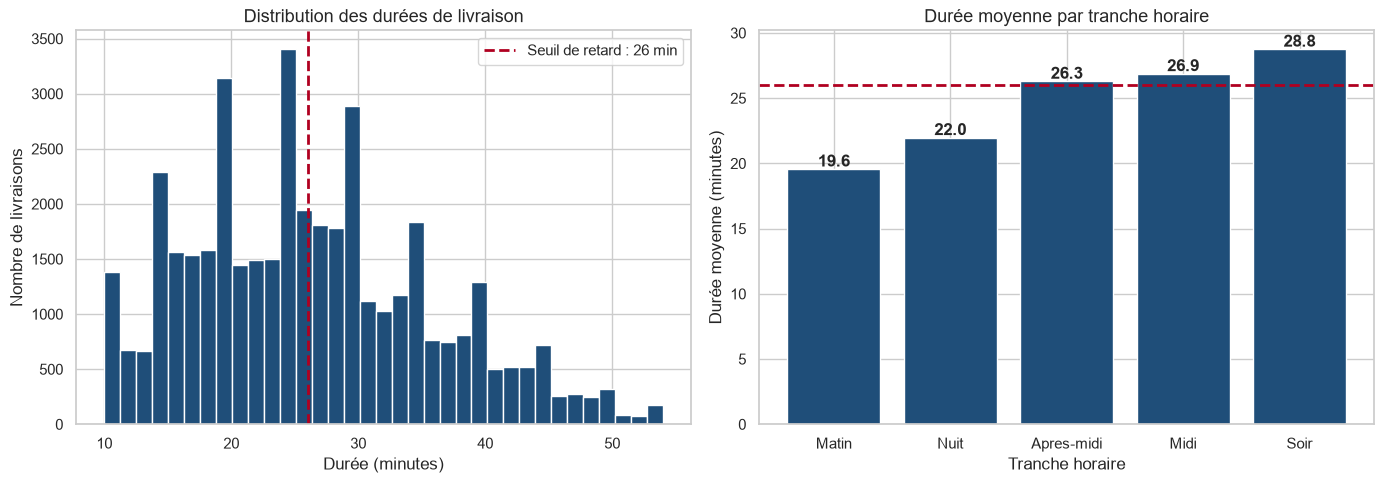

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des durées
axes[0].hist(donnees["duree"], bins=35, color="#1f4e79", edgecolor="white")
axes[0].axvline(SEUIL_RETARD, color="#b00020", linestyle="--", linewidth=2,
                label=f"Seuil de retard : {SEUIL_RETARD:.0f} min")
axes[0].set_title("Distribution des durées de livraison")
axes[0].set_xlabel("Durée (minutes)")
axes[0].set_ylabel("Nombre de livraisons")
axes[0].legend()

# Durée et taux de retard par tranche horaire
donnees_graphique = par_tranche.sort_values("duree_moyenne")
barres = axes[1].bar(donnees_graphique.index, donnees_graphique["duree_moyenne"],
                     color="#1f4e79")
for barre, valeur in zip(barres, donnees_graphique["duree_moyenne"]):
    axes[1].text(barre.get_x() + barre.get_width() / 2, barre.get_height() + 0.2,
                 f"{valeur:.1f}", ha="center", fontweight="bold")
axes[1].axhline(SEUIL_RETARD, color="#b00020", linestyle="--", linewidth=2)
axes[1].set_title("Durée moyenne par tranche horaire")
axes[1].set_xlabel("Tranche horaire")
axes[1].set_ylabel("Durée moyenne (minutes)")

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V1_V2_distribution_et_tranches.png", dpi=110)
plt.show()

In [58]:
# Test de l'hypothèse H3 : les heures de pointe concentrent-elles les retards ?
pointe = donnees.loc[donnees["est_pointe"], "duree"]
autres = donnees.loc[~donnees["est_pointe"], "duree"]
test_pointe = stats.mannwhitneyu(pointe, autres, alternative="two-sided")

# Comparaison avec / sans heures de pointe, et avec / sans week-end
pd.DataFrame([
    {"comparaison": g,
     "durée moyenne (min)": round(x, 2),
     "taux de retard (%)": round(100 * donnees.loc[m, "en_retard"].mean(), 2)}
    for g, x, m in [("Heures de pointe", pointe.mean(), donnees["est_pointe"]),
                    ("Autres heures", autres.mean(), ~donnees["est_pointe"]),
                    ("Jour de semaine", donnees.loc[~donnees["est_weekend"], "duree"].mean(),
                     ~donnees["est_weekend"]),
                    ("Week-end", donnees.loc[donnees["est_weekend"], "duree"].mean(),
                     donnees["est_weekend"])]
]).set_index("comparaison").T

comparaison,Heures de pointe,Autres heures,Jour de semaine,Week-end
durée moyenne (min),27.58,25.52,26.35,26.21
taux de retard (%),50.96,42.20,45.75,45.07


## Tâche 6 - Axe Espace

Effet de la distance, comparaison des villes et carte des zones à retard
élevé.

In [59]:
correlation_distance = donnees["distance_km"].corr(donnees["duree"])
pente = np.polyfit(donnees["distance_km"], donnees["duree"], 1)[0]

par_distance = par_categorie("classe_distance",
                             ["< 2 km", "2-5 km", "5-10 km", "10-20 km", "> 20 km"])
par_ville = par_categorie("ville")

pd.DataFrame({
    "indicateur": ["Corrélation distance / durée", "Minutes ajoutées par km (K9)",
                   "Distance médiane", "Durée médiane"],
    "valeur": [f"{correlation_distance:.3f}", f"{pente:.3f} min/km",
               f"{donnees['distance_km'].median():.2f} km",
               f"{donnees['duree'].median():.2f} min"],
}).set_index("indicateur").T

indicateur,Corrélation distance / durée,Minutes ajoutées par km (K9),Distance médiane,Durée médiane
valeur,0.321,0.538 min/km,9.19 km,26.00 min


In [60]:
# Le tableau par ville fait apparaître un groupe très petit : le KPI K12
# impose de contrôler les effectifs avant de conclure.
par_ville.assign(
    conclusion_possible=par_ville["nombre"] >= SEUIL_MIN_LIVRAISONS
).sort_values("duree_moyenne")

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues,conclusion_possible
ville,,,,,,
Inconnu,1097,22.11,21.0,27.89,1.94,True
Urbaine,9175,23.03,22.0,31.65,2.43,True
Metropolitaine,31103,27.32,27.0,50.04,4.36,True
Semi-urbaine,147,49.68,49.0,100.00,23.68,True


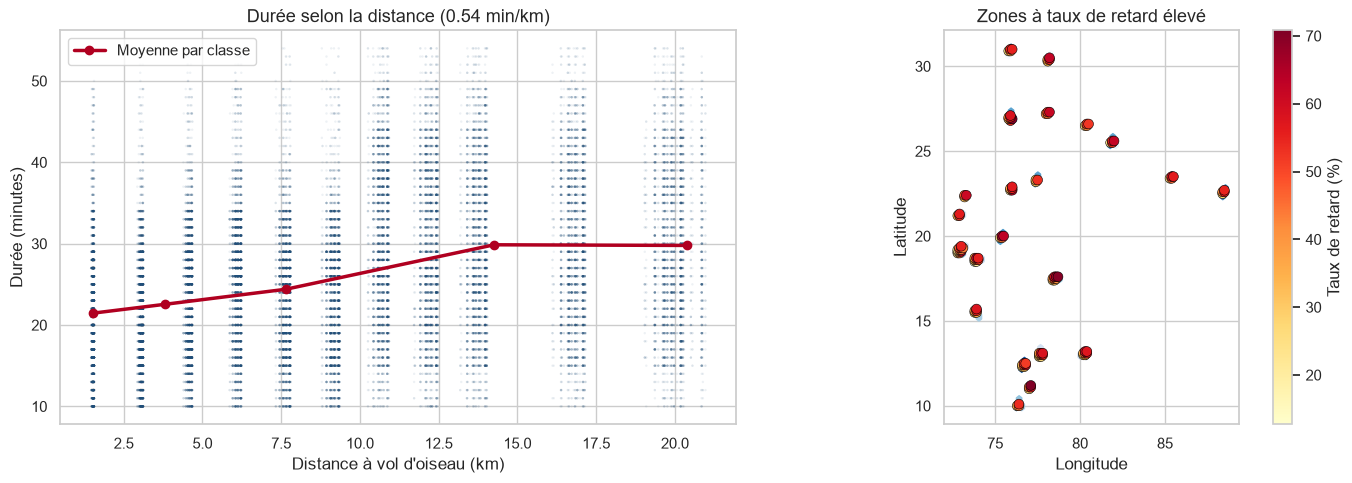

In [61]:
moyennes_classe = donnees.groupby("classe_distance", observed=True).agg(
    distance=("distance_km", "mean"), duree=("duree", "mean")).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance et durée
axes[0].scatter(donnees["distance_km"], donnees["duree"], s=3, alpha=0.08,
                color="#1f4e79", edgecolors="none")
axes[0].plot(moyennes_classe["distance"], moyennes_classe["duree"], "o-",
             color="#b00020", linewidth=2.5, label="Moyenne par classe")
axes[0].set_title(f"Durée selon la distance ({pente:.2f} min/km)")
axes[0].set_xlabel("Distance à vol d'oiseau (km)")
axes[0].set_ylabel("Durée (minutes)")
axes[0].legend()

# Zones à retard élevé, sur grille géographique
donnees_carte = donnees.copy()
donnees_carte["case_lat"] = donnees_carte["Delivery_location_latitude"].round(1)
donnees_carte["case_lon"] = donnees_carte["Delivery_location_longitude"].round(1)
zones = donnees_carte.groupby(["case_lat", "case_lon"], observed=True).agg(
    nombre=("duree", "count"), taux_retard=("en_retard", lambda x: 100 * x.mean())
).round(2)
zones = zones[zones["nombre"] >= 30]

echantillon = donnees.sample(min(20000, len(donnees)), random_state=1)
axes[1].hexbin(echantillon["Delivery_location_longitude"],
               echantillon["Delivery_location_latitude"],
               gridsize=50, cmap="Blues", mincnt=1, bins="log")
scatter = axes[1].scatter(zones.index.get_level_values("case_lon"),
                          zones.index.get_level_values("case_lat"),
                          s=50, c=zones["taux_retard"], cmap="YlOrRd",
                          edgecolors="black", linewidths=0.4)
axes[1].set_title("Zones à taux de retard élevé")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal")
plt.colorbar(scatter, ax=axes[1], label="Taux de retard (%)")

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V7_V9_distance_et_zones.png", dpi=110)
plt.show()

## Tâche 7 - Axe Conditions

Comparaison des durées selon le trafic et la météo, puis test de l'effet
combiné (hypothèses H2 et H6).

In [62]:
ORDRE_TRAFIC = ["Low", "Medium", "High", "Jam", "Inconnu"]
par_trafic = par_categorie("Road_traffic_density", ORDRE_TRAFIC)
par_trafic

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
Road_traffic_density,,,,,
Low,14095,21.28,20.0,20.81,1.10
Medium,10023,26.74,27.0,50.20,3.85
High,4046,27.21,27.0,54.13,3.91
Jam,12950,31.19,31.0,66.19,7.11
Inconnu,408,26.34,26.0,47.55,4.01


In [63]:
# Regroupement de la météo en deux familles (sinon six catégories difficiles à comparer)
donnees["meteo_groupe"] = "Neutre"
donnees.loc[donnees["meteo"].isin(["Sunny", "Windy"]), "meteo_groupe"] = "Favorable"
donnees.loc[donnees["meteo"].isin(["Fog", "Stormy", "Sandstorms"]), "meteo_groupe"] = "Severe"

par_meteo = par_categorie("meteo_groupe", ["Favorable", "Neutre", "Severe"])
par_meteo

,nombre,duree_moyenne,duree_mediane,taux_retard,minutes_perdues
meteo_groupe,,,,,
Favorable,13474,24.03,23.0,34.57,2.64
Neutre,7301,28.79,28.0,56.66,5.70
Severe,20747,26.93,26.0,48.81,4.17


In [64]:
bas = donnees.loc[donnees["Road_traffic_density"] == "Low", "duree"]
bouche = donnees.loc[donnees["Road_traffic_density"] == "Jam", "duree"]
fav = donnees.loc[donnees["meteo_groupe"] == "Favorable", "duree"]
sev = donnees.loc[donnees["meteo_groupe"] == "Severe", "duree"]

ecart_trafic = bouche.mean() - bas.mean()
ecart_meteo = sev.mean() - fav.mean()
p_trafic = stats.mannwhitneyu(bouche, bas, alternative="two-sided").pvalue
p_meteo = stats.mannwhitneyu(sev, fav, alternative="two-sided").pvalue

pd.DataFrame([
    {"facteur": "Trafic (fluide vs embouteillé)", "durée A": round(bas.mean(), 2),
     "durée B": round(bouche.mean(), 2), "écart (min)": round(ecart_trafic, 2),
     "p-value": f"{p_trafic:.1e}"},
    {"facteur": "Météo (favorable vs sévère)", "durée A": round(fav.mean(), 2),
     "durée B": round(sev.mean(), 2), "écart (min)": round(ecart_meteo, 2),
     "p-value": f"{p_meteo:.1e}"},
]).set_index("facteur")

,durée A,durée B,écart (min),p-value
facteur,,,,
Trafic (fluide vs embouteillé),21.28,31.19,9.91,0.0e+00
Météo (favorable vs sévère),24.03,26.93,2.89,1.2e-193


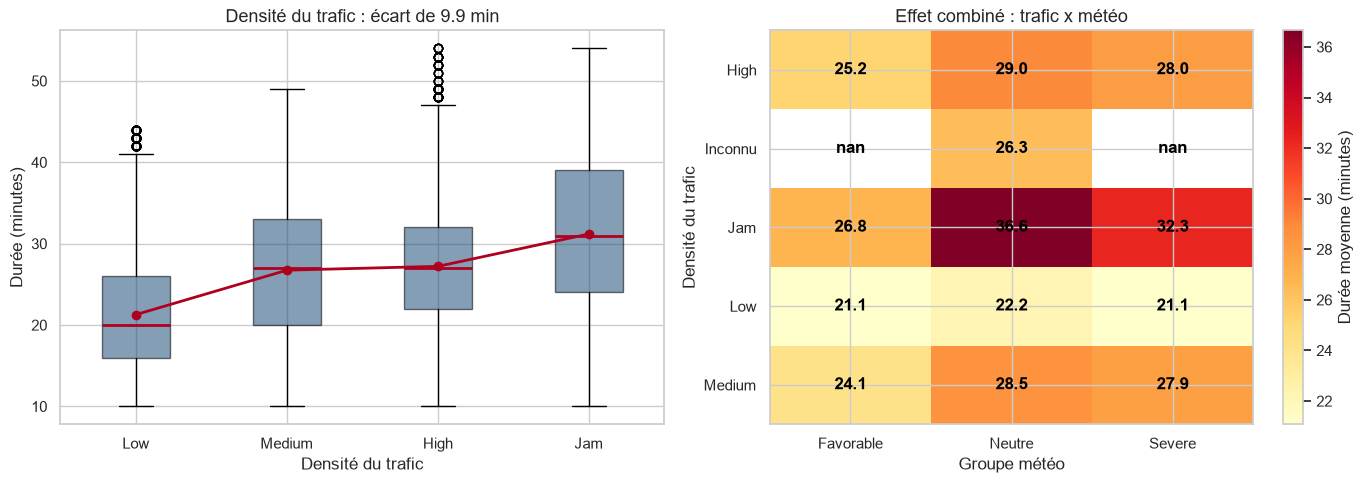

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

niveaux = ["Low", "Medium", "High", "Jam"]
axes[0].boxplot([donnees.loc[donnees["Road_traffic_density"] == n, "duree"] for n in niveaux],
               tick_labels=niveaux, patch_artist=True,
               boxprops={"facecolor": "#1f4e79", "alpha": 0.55},
               medianprops={"color": "#b00020", "linewidth": 2})
axes[0].plot(range(1, 5), [par_trafic.loc[n, "duree_moyenne"] for n in niveaux],
             "o-", color="#b00020", linewidth=2)
axes[0].set_title(f"Densité du trafic : écart de {ecart_trafic:.1f} min")
axes[0].set_xlabel("Densité du trafic")
axes[0].set_ylabel("Durée (minutes)")

croise = donnees.pivot_table(index="Road_traffic_density", columns="meteo_groupe",
                            values="duree", aggfunc="mean", observed=True).round(2)
im = axes[1].imshow(croise.to_numpy(dtype=float), cmap="YlOrRd", aspect="auto")
for i in range(croise.shape[0]):
    for j in range(croise.shape[1]):
        valeur = croise.to_numpy(dtype=float)[i, j]
        axes[1].text(j, i, f"{valeur:.1f}", ha="center", va="center",
                     fontweight="bold",
                     color="white" if valeur > croise.to_numpy(dtype=float).mean() else "black")
axes[1].set_xticks(range(len(croise.columns)), croise.columns)
axes[1].set_yticks(range(len(croise.index)), croise.index)
axes[1].set_title("Effet combiné : trafic x météo")
axes[1].set_xlabel("Groupe météo")
axes[1].set_ylabel("Densité du trafic")
plt.colorbar(im, ax=axes[1], label="Durée moyenne (minutes)")

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V4_V6_trafic_meteo.png", dpi=110)
plt.show()

In [66]:
# H6 : les deux facteurs se cumulent-ils ?
duree_ref = donnees[(donnees["Road_traffic_density"] == "Low") &
                    (donnees["meteo_groupe"] == "Favorable")]["duree"].mean()
duree_trafic = donnees[(donnees["Road_traffic_density"].isin(["High", "Jam"])) &
                       (donnees["meteo_groupe"] == "Favorable")]["duree"].mean()
duree_meteo = donnees[(donnees["Road_traffic_density"] == "Low") &
                      (donnees["meteo_groupe"] == "Severe")]["duree"].mean()
duree_cumul = donnees[(donnees["Road_traffic_density"].isin(["High", "Jam"])) &
                      (donnees["meteo_groupe"] == "Severe")]["duree"].mean()
duree_prevue = duree_ref + (duree_trafic - duree_ref) + (duree_meteo - duree_ref)

pd.DataFrame([
    {"situation": "Fluide + météo favorable (référence)", "durée (min)": round(duree_ref, 2)},
    {"situation": "Trafic dense seul", "durée (min)": round(duree_trafic, 2)},
    {"situation": "Météo sévère seule", "durée (min)": round(duree_meteo, 2)},
    {"situation": "Les deux ensemble", "durée (min)": round(duree_cumul, 2)},
    {"situation": "Si les effets s'additionnaient", "durée (min)": round(duree_prevue, 2)},
]).set_index("situation")

,durée (min)
situation,
Fluide + météo favorable (référence),21.10
Trafic dense seul,26.37
Météo sévère seule,21.08
Les deux ensemble,31.27
Si les effets s'additionnaient,26.36


## Tâche 8 - Axe Véhicule

La comparaison directe des durées est biaisée : les véhicules neffectuent pas
les mêmes trajets. On compare donc l'**efficacité par kilomètre** et on
croise avec la classe de distance.

In [67]:
donnees["minutes_par_km"] = donnees["duree"] / donnees["distance_km"]

par_vehicule = par_categorie("vehicule")
efficacite = donnees.groupby("vehicule", observed=True).agg(
    nombre=("minutes_par_km", "count"),
    minutes_par_km=("minutes_par_km", "mean")).round(3).sort_values("minutes_par_km")

efficacite

,nombre,minutes_par_km
vehicule,,
electric scooter,3404,3.889
scooter,13878,3.903
bicycle,43,4.073
motorcycle,24197,4.457


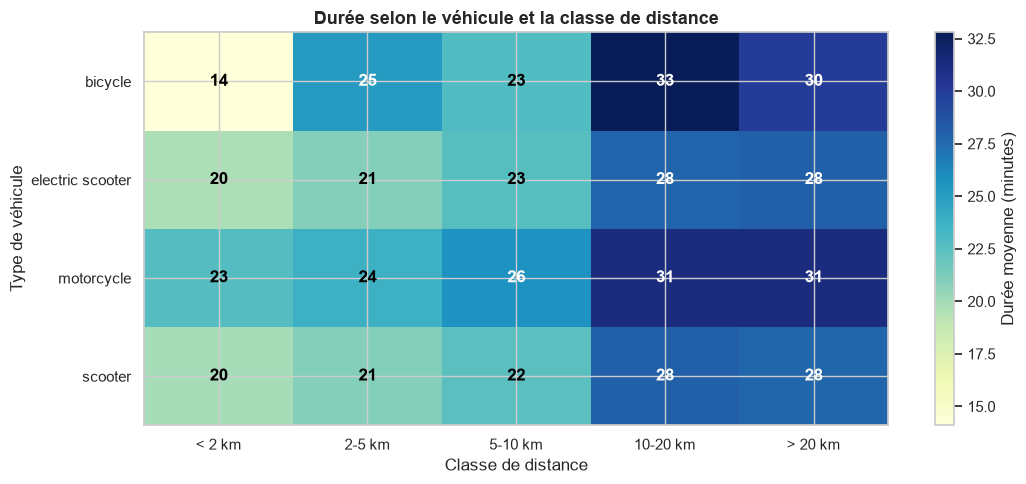

classe_distance,< 2 km,2-5 km,5-10 km,10-20 km,> 20 km
vehicule,,,,,
bicycle,14.1,25.2,22.8,32.8,30.0
electric scooter,19.6,20.9,22.6,27.8,28.0
motorcycle,22.7,23.7,25.7,31.2,31.2
scooter,19.8,20.9,22.5,28.0,27.7


In [68]:
tableau_vehicule = donnees.pivot_table(index="vehicule", columns="classe_distance",
                                      values="duree", aggfunc="mean",
                                      observed=True).round(1)

plt.figure(figsize=(11, 5))
valeurs = tableau_vehicule.to_numpy(dtype=float)
plt.imshow(valeurs, cmap="YlGnBu", aspect="auto")
for i in range(valeurs.shape[0]):
    for j in range(valeurs.shape[1]):
        plt.text(j, i, f"{valeurs[i, j]:.0f}", ha="center", va="center",
                 fontweight="bold",
                 color="white" if valeurs[i, j] > valeurs.mean() else "black")
plt.colorbar(label="Durée moyenne (minutes)")
plt.xticks(range(len(tableau_vehicule.columns)), tableau_vehicule.columns)
plt.yticks(range(len(tableau_vehicule.index)), tableau_vehicule.index)
plt.title("Durée selon le véhicule et la classe de distance", fontweight="bold")
plt.xlabel("Classe de distance")
plt.ylabel("Type de véhicule")
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V8_vehicule_par_distance.png", dpi=110)
plt.show()

tableau_vehicule

## Tâche 9 - Axe Coût

Les minutes perdues sont cumulées par condition, et les gains possibles sont
chiffrés à partir des écarts observés entre situations comparables.

In [69]:
concentration = donnees.groupby(["Road_traffic_density", "meteo_groupe"],
                                 observed=True).agg(
    nombre=("duree", "count"),
    minutes_perdues_total=("minutes_perdues", "sum"),
    cout_total=("cout_retard", "sum"),
    taux_retard=("en_retard", lambda x: 100 * x.mean()),
).round(2)
concentration = concentration[concentration["nombre"] >= 100]
concentration = concentration.sort_values("minutes_perdues_total", ascending=False)

# Les dix premières conditions qui concentrent le plus de temps perdu
concentration.head(10)

nombre  minutes_perdues_total  cout_total  taux_retard
Road_traffic_density meteo_groupe                                                        
Jam                  Severe          6538                50028.0   1000560.0        72.27
                     Neutre          2152                23464.0    469280.0        87.45
Medium               Severe          5014                21545.0    430900.0        55.80
Jam                  Favorable       4260                18599.0    371980.0        46.13
Medium               Neutre          1681                 9598.0    191960.0        60.50
High                 Severe          2014                 8146.0    162920.0        59.14
Medium               Favorable       3328                 7425.0    148500.0        36.57
Low                  Severe          7181                 6704.0    134080.0        19.66
High                 Favorable       1352                 5135.0    102700.0        39.64
Low                  Favorable       4534                 4387.0     87740.0        20.73

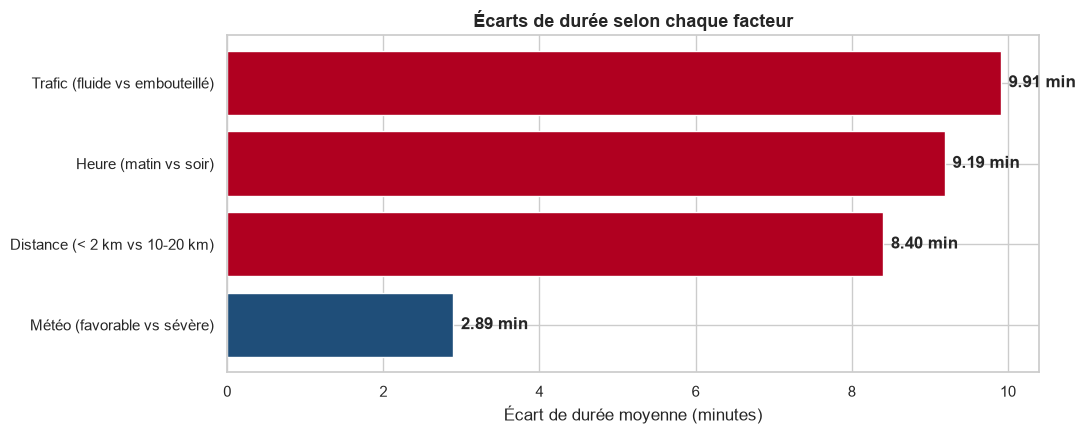

,écart de durée (min)
Météo (favorable vs sévère),2.89
Distance (< 2 km vs 10-20 km),8.40
Heure (matin vs soir),9.19
Trafic (fluide vs embouteillé),9.91


In [70]:
# Écarts de durée par facteur : le graphique de synthèse (visualisation V11)
ecarts = pd.Series({
    "Trafic (fluide vs embouteillé)": ecart_trafic,
    "Heure (matin vs soir)": par_tranche.loc["Soir", "duree_moyenne"]
                           - par_tranche.loc["Matin", "duree_moyenne"],
    "Distance (< 2 km vs 10-20 km)": par_distance.loc["10-20 km", "duree_moyenne"]
                                  - par_distance.loc["< 2 km", "duree_moyenne"],
    "Météo (favorable vs sévère)": ecart_meteo,
}).sort_values()

plt.figure(figsize=(11, 4.5))
barres = plt.barh(ecarts.index, ecarts.values,
                  color=["#b00020" if v >= 5 else "#1f4e79" for v in ecarts.values])
for barre, valeur in zip(barres, ecarts.values):
    plt.text(valeur + 0.1, barre.get_y() + barre.get_height() / 2,
             f"{valeur:.2f} min", va="center", fontweight="bold")
plt.title("Écarts de durée selon chaque facteur", fontweight="bold")
plt.xlabel("Écart de durée moyenne (minutes)")
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V11_ecarts_par_facteur.png", dpi=110)
plt.show()

ecarts.round(2).to_frame("écart de durée (min)")

---
# Partie C - Croiser et comparer (tâches 10 à 12)

## Tâche 10 - Corrélations et tableaux croisés

Une corrélation mesure une **association**, jamais une causalité. La note du
livreur apparaît ici sans qu'elle « cause » un retard : les livreurs bien notés
reçoivent les tournées les plus difficiles. C'est un facteur de confusion.

Les modalites **Inconnu** sont exclues du calcul : leur affecter un niveau ordinal (0) les ferait entrer dans la correlation comme si elles etaient une situation reelle.

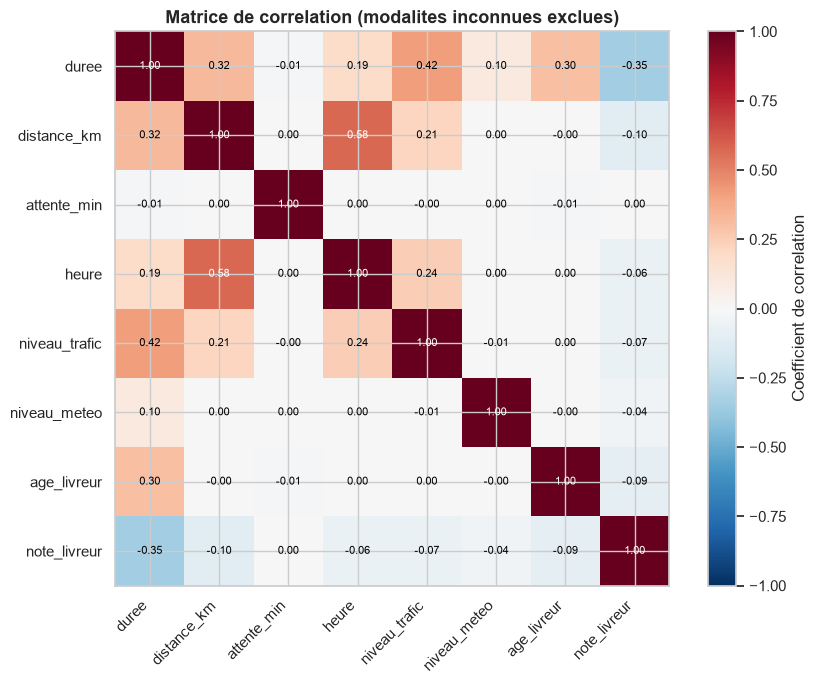

In [71]:
# Les modalites "Inconnu" sont encodees a 0 pour rester calculables, mais 0
# signifie ici "on ne sait pas" et non "trafic fluide". Les conserver fausserait
# la correlation : on les remplace par NaN, que pandas ignore (suppression par
# paire). Chaque case est donc calculee sur les lignes ou les deux variables
# sont connues.
donnees_correlation = donnees.copy()
donnees_correlation[["niveau_trafic", "niveau_meteo"]] = (
    donnees_correlation[["niveau_trafic", "niveau_meteo"]].replace(0, np.nan))

variables = ["duree", "distance_km", "attente_min", "heure", "niveau_trafic",
             "niveau_meteo", "age_livreur", "note_livreur"]
matrice = donnees_correlation[variables].corr()

# Effectifs effectivement utilises pour les deux correlations sensibles
modalites_ignorees = pd.DataFrame([
    {"variable": nom,
     "lignes ignorees": int(donnees_correlation[nom].isna().sum()),
     "lignes utilisees": int(donnees_correlation[nom].notna().sum())}
    for nom in ["niveau_trafic", "niveau_meteo"]
])
modalites_ignorees

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matrice.to_numpy(dtype=float), cmap="RdBu_r", vmin=-1, vmax=1)
for i in range(len(variables)):
    for j in range(len(variables)):
        valeur = matrice.to_numpy(dtype=float)[i, j]
        ax.text(j, i, f"{valeur:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(valeur) > 0.45 else "black")
ax.set_xticks(range(len(variables)), variables, rotation=45, ha="right")
ax.set_yticks(range(len(variables)), variables)
ax.set_title("Matrice de correlation (modalites inconnues exclues)", fontweight="bold")
plt.colorbar(im, ax=ax, label="Coefficient de correlation")
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V10_matrice_correlation.png", dpi=110)
plt.show()


## Tâche 11 - Comparaisons statistiques

Trois contrôles de fiabilité : les effectifs (K12), la précision de l'écart
mesuré, et l'utilité réelle de l'effet.

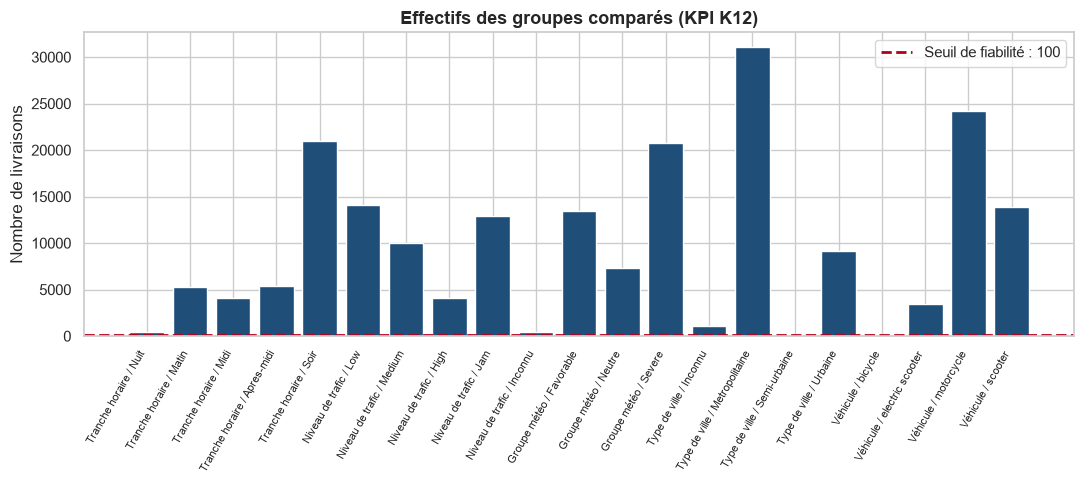

,comparaison,modalité,effectif,conclusion possible
17,Véhicule,bicycle,43,NON


In [72]:
# KPI K12 : effectifs des groupes comparés. Un groupe de moins de
# SEUIL_MIN_LIVRAISONS observations ne permet aucune conclusion.
groupes = {
    "Tranche horaire": par_tranche["nombre"],
    "Niveau de trafic": par_trafic["nombre"],
    "Groupe météo": par_meteo["nombre"],
    "Type de ville": par_ville["nombre"],
    "Véhicule": par_vehicule["nombre"],
}
kpi_k12 = pd.DataFrame(
    [{"comparaison": nom, "modalité": modalite, "effectif": int(effectif),
      "conclusion possible": "oui" if effectif >= SEUIL_MIN_LIVRAISONS else "NON"}
     for nom, serie in groupes.items() for modalite, effectif in serie.items()]
)

plt.figure(figsize=(11, 5))
petits = kpi_k12[~kpi_k12["conclusion possible"].eq("oui")]
couleurs = ["#1f4e79" if v else "#b00020"
            for v in kpi_k12["conclusion possible"].eq("oui")]
plt.bar(range(len(kpi_k12)), kpi_k12["effectif"], color=couleurs)
plt.axhline(SEUIL_MIN_LIVRAISONS, color="#b00020", linestyle="--", linewidth=2,
            label=f"Seuil de fiabilité : {SEUIL_MIN_LIVRAISONS}")
plt.xticks(range(len(kpi_k12)),
           [c + " / " + m for c, m in zip(kpi_k12["comparaison"], kpi_k12["modalité"])],
           rotation=60, ha="right", fontsize=8)
plt.ylabel("Nombre de livraisons")
plt.title("Effectifs des groupes comparés (KPI K12)", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V12_effectifs_groupes.png", dpi=110)
plt.show()

kpi_k12[~kpi_k12["conclusion possible"].eq("oui")]

In [73]:
# Précision de l'écart : intervalle de confiance par ré-échantillonnage.
# Et utilité de l'effet : une corrélation peut être significative sans
# être exploitable (c'est le cas du temps d'attente).
aleatoire = np.random.default_rng(1)
ecarts_trafic = [aleatoire.choice(bouche.values, len(bouche)).mean()
                 - aleatoire.choice(bas.values, len(bas)).mean()
                 for _ in range(1000)]
intervalle = np.percentile(ecarts_trafic, [2.5, 97.5])

correlation_attente = donnees["attente_min"].corr(donnees["duree"])

pd.DataFrame([
    {"mesure": "Écart trafic (fluide vs embouteillé)",
     "effet estimé": f"{ecart_trafic:.2f} min",
     "intervalle 95%": f"[{intervalle[0]:.2f} ; {intervalle[1]:.2f}]",
     "exploitable": "oui"},
    {"mesure": "Écart météo (favorable vs sévère)",
     "effet estimé": f"{ecart_meteo:.2f} min",
     "intervalle 95%": "—",
     "exploitable": "oui"},
    {"mesure": "Corrélation temps d'attente / durée",
     "effet estimé": f"{correlation_attente:.3f}",
     "intervalle 95%": "—",
     "exploitable": "NON (effet négligeable)"},
]).set_index("mesure")

,effet estimé,intervalle 95%,exploitable
mesure,,,
Écart trafic (fluide vs embouteillé),9.91 min,[9.71 ; 10.12],oui
Écart météo (favorable vs sévère),2.89 min,—,oui
Corrélation temps d'attente / durée,-0.010,—,NON (effet négligeable)


## Tâche 12 - Tableau de bord des KPI

Synthèse des indicateurs, sous forme de tableau puis de graphique.

In [74]:
indicateurs = pd.DataFrame([
    ("Délais", "Durée médiane (K1)", f"{donnees['duree'].median():.1f}", "min"),
    ("Délais", "Durée moyenne", f"{donnees['duree'].mean():.1f}", "min"),
    ("Délais", "Écart pire / meilleur créneau (K6)",
     f"{par_tranche['duree_moyenne'].max() - par_tranche['duree_moyenne'].min():.1f}", "min"),
    ("Délais", "Minutes perdues par livraison (K3)",
     f"{donnees['minutes_perdues'].mean():.2f}", "min"),
    ("Retards", "Taux de retard (K2)", f"{100 * donnees['en_retard'].mean():.1f}", "%"),
    ("Retards", "Temps perdu sur la période (K4)", f"{minutes_total/1440:,.0f}", "jours"),
    ("Conditions", "Trafic dense vs fluide (K7)", f"{ecart_trafic:.1f}", "min"),
    ("Conditions", "Météo sévère vs favorable (K8)", f"{ecart_meteo:.1f}", "min"),
    ("Espace", "Minutes ajoutées par km (K9)", f"{pente:.2f}", "min/km"),
    ("Espace", "Corrélation distance / durée", f"{correlation_distance:.2f}", "coef."),
    ("Qualité", "Conservation des données (K11)", f"{taux_conservation:.1f}", "%"),
    ("Qualité", "Groupes non concluants (K12)", f"{len(petits)}", "groupes"),
], columns=["Catégorie", "Indicateur", "Valeur", "Unité"])

indicateurs

,Catégorie,Indicateur,Valeur,Unité
0,Délais,Durée médiane (K1),26.0,min
1,Délais,Durée moyenne,26.3,min
2,Délais,Écart pire / meilleur créneau (K6),9.2,min
3,Délais,Minutes perdues par livraison (K3),3.94,min
4,Retards,Taux de retard (K2),45.6,%
5,Retards,Temps perdu sur la période (K4),114,jours
6,Conditions,Trafic dense vs fluide (K7),9.9,min
7,Conditions,Météo sévère vs favorable (K8),2.9,min
8,Espace,Minutes ajoutées par km (K9),0.54,min/km
9,Espace,Corrélation distance / durée,0.32,coef.


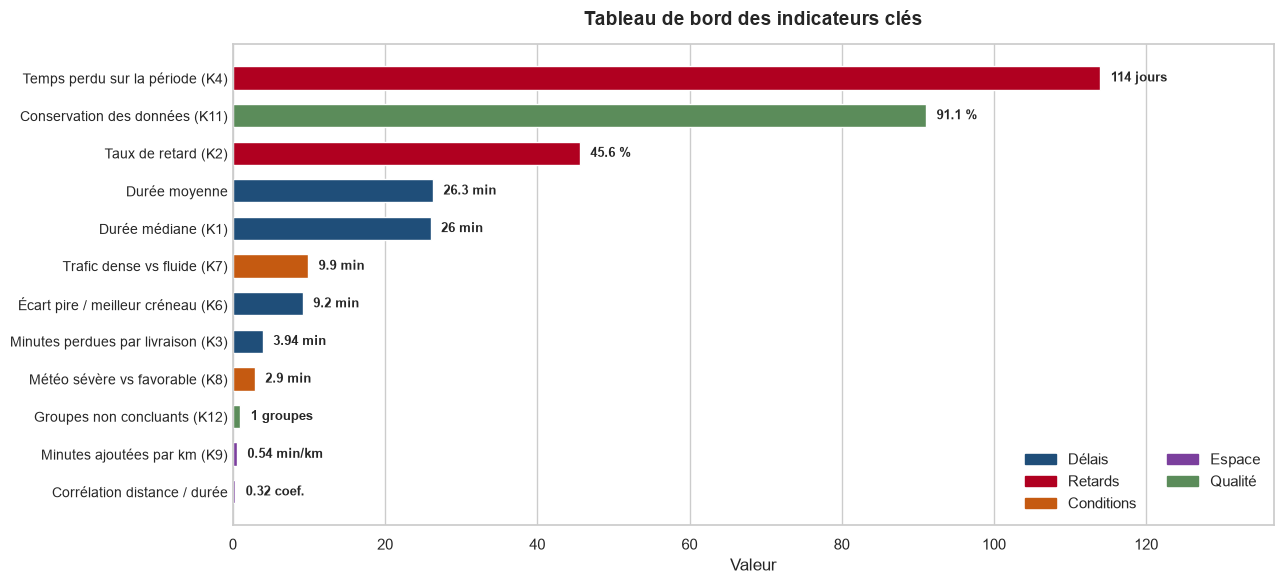

In [75]:
# Même contenu sous forme graphique. Les barres sont ordonnées par valeur et
# colorées par catégorie : la longueur rend immédiatement compte de l'ampleur
# de chaque indicateur.
couleurs_cat = {"Délais": "#1f4e79", "Retards": "#b00020",
                "Conditions": "#c55a11", "Espace": "#7b3f9d", "Qualité": "#5b8c5a"}

vue = indicateurs.assign(
    valeur_num=indicateurs["Valeur"].str.replace(",", ".", regex=False).astype(float)
).sort_values("valeur_num")

fig, ax = plt.subplots(figsize=(13, 6))
barres = ax.barh(vue["Indicateur"], vue["valeur_num"],
                 color=[couleurs_cat[c] for c in vue["Catégorie"]], height=0.62)
for barre, valeur, unite in zip(barres, vue["valeur_num"], vue["Unité"]):
    ax.text(valeur + vue["valeur_num"].max() * 0.012,
            barre.get_y() + barre.get_height() / 2,
            f"{valeur:g} {unite}", va="center", fontsize=9, fontweight="bold")

ax.set_title("Tableau de bord des indicateurs clés", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Valeur")
ax.set_xlim(0, vue["valeur_num"].max() * 1.2)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0, labelsize=10)

legende = [plt.Rectangle((0, 0), 1, 1, color=color) for color in couleurs_cat.values()]
ax.legend(legende, list(couleurs_cat), loc="lower right", frameon=False, ncol=2)

plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V13_tableau_de_bord_kpi.png", dpi=110)
plt.show()

---
# Partie D - Conclure et livrer (tâches 13 à 16)

## Tâche 13 - Scénarios et recommandations

Chaque gain est calculé en rejouant une situation **réellement observée** :
on mesure ce qu'ont duré les livraisons comparables dans de meilleures
conditions, et on applique la différence aux livraisons défavorables. Aucune
livraison n'est inventée.

In [76]:
def gain_situation(contexte, reference, nom, hypothese, limite):
    """Gain estimé d'un levier : situation observée moins situation de référence."""
    reference_par_classe = donnees[reference].groupby(
        "classe_distance", observed=True)["duree"].mean()
    gain_unitaire = (contexte["duree"].astype(float).to_numpy()
                     - contexte["classe_distance"].map(reference_par_classe)
                     .astype(float).to_numpy()).mean()
    return {"scenario": nom,
            "livraisons concernées": len(contexte),
            "durée actuelle (min)": round(contexte["duree"].mean(), 2),
            "gain / livraison (min)": round(gain_unitaire, 2),
            "gain total (min)": round(gain_unitaire * len(contexte)),
            "hypothèse": hypothese,
            "limite": limite}


# Attention aux noms : ces masques booléens écraseraient les séries de durées
# utilisées plus haut pour les tests statistiques.
masque_jam = donnees["Road_traffic_density"] == "Jam"
masque_faible = donnees["Road_traffic_density"] == "Low"
masque_pointe = donnees["est_pointe"]
masque_severe = donnees["meteo_groupe"] == "Severe"
masque_favorable = donnees["meteo_groupe"] == "Favorable"

# Le véhicule n'a pas d'étiquette « bonne » ou « mauvaise » : on mesure le
# bénéfice d'un choix adapté, par rapport au véhicule le plus rapide du marché
# pour la même classe de distance.
durees_par_vehicule = donnees.pivot_table(
    index="vehicule", columns="classe_distance", values="duree",
    aggfunc="mean", observed=True)
meilleur_par_classe = durees_par_vehicule.idxmin()
meilleure_duree = donnees["classe_distance"].map(
    durees_par_vehicule.min().astype(float)).astype(float)
gain_vehicule = float((donnees["duree"].astype(float) - meilleure_duree).mean())

scenarios = pd.DataFrame([
    gain_situation(donnees[masque_jam], masque_faible,
                   "Planifier hors des zones congestionnées",
                   "À distance comparable, un trajet en trafic fluide dure moins longtemps.",
                   "Le report modal n'est pas vérifiable ici."),
    gain_situation(donnees[masque_pointe], ~masque_pointe,
                   "Décaler les livraisons hors des pointes",
                   "À distance comparable, une livraison hors pointe dure moins longtemps.",
                   "Le client choisit son heure de commande."),
    gain_situation(donnees[masque_severe], masque_favorable,
                   "Prévoir une marge par mauvais temps",
                   "À distance comparable, la météo sévère allonge la durée.",
                   "La météo n'est pas contrôlable : le levier est l'anticipation."),
    {"scenario": "Adapter le véhicule au type de trajet",
     "livraisons concernées": len(donnees),
     "durée actuelle (min)": round(donnees["duree"].mean(), 2),
     "gain / livraison (min)": round(gain_vehicule, 2),
     "gain total (min)": round(gain_vehicule * len(donnees)),
     "hypothèse": "Meilleur véhicule par classe de distance, à distance comparable.",
     "limite": "Le coût d'acquisition n'est pas mesuré."},
]).sort_values("gain total (min)", ascending=False)

scenarios[["scenario", "livraisons concernées", "durée actuelle (min)",
           "gain / livraison (min)", "gain total (min)"]]

,scenario,livraisons concernées,durée actuelle (min),gain / livraison (min),gain total (min)
0,Planifier hors des zones congestionnées,12950,31.19,8.78,113641
3,Adapter le véhicule au type de trajet,41522,26.32,2.39,99173
2,Prévoir une marge par mauvais temps,20747,26.93,2.88,59733
1,Décaler les livraisons hors des pointes,15966,27.58,1.88,29994


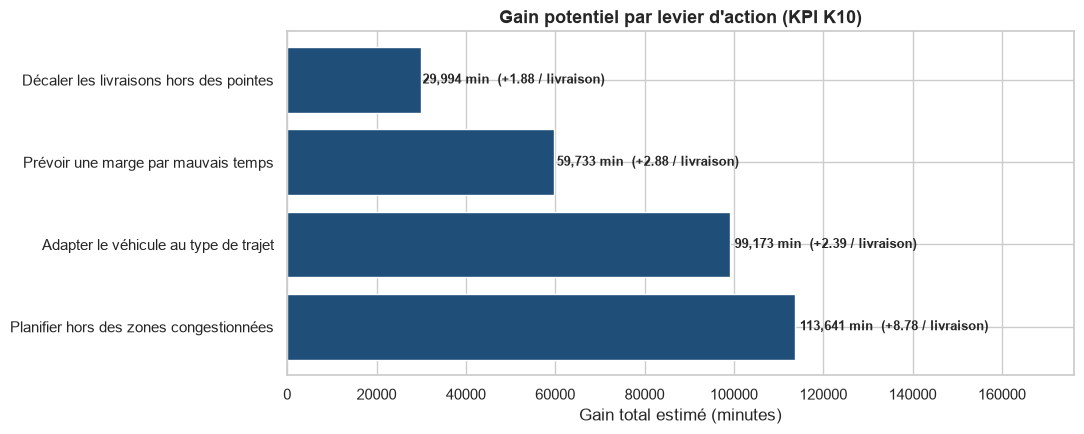

scenario,Planifier hors des zones congestionnées,Adapter le véhicule au type de trajet,Prévoir une marge par mauvais temps,Décaler les livraisons hors des pointes
hypothèse,"À distance comparable, un trajet en trafic flu...","Meilleur véhicule par classe de distance, à di...","À distance comparable, la météo sévère allonge...","À distance comparable, une livraison hors poin..."
limite,Le report modal n'est pas vérifiable ici.,Le coût d'acquisition n'est pas mesuré.,La météo n'est pas contrôlable : le levier est...,Le client choisit son heure de commande.


In [77]:
plt.figure(figsize=(11, 4.5))
barres = plt.barh(scenarios["scenario"], scenarios["gain total (min)"], color="#1f4e79")
for barre, valeur, unite in zip(barres, scenarios["gain total (min)"],
                                scenarios["gain / livraison (min)"]):
    plt.text(valeur * 1.01, barre.get_y() + barre.get_height() / 2,
             f"{valeur:,.0f} min  ({unite:+.2f} / livraison)",
             va="center", fontsize=9, fontweight="bold")
plt.xlabel("Gain total estimé (minutes)")
plt.title("Gain potentiel par levier d'action (KPI K10)", fontweight="bold")
plt.xlim(0, scenarios["gain total (min)"].max() * 1.55)
plt.tight_layout()
plt.savefig(DOSSIER_FIGURES / "V14_gains_par_scenario.png", dpi=110)
plt.show()

scenarios.set_index("scenario")[["hypothèse", "limite"]].T

In [78]:
scenarios.to_csv(DOSSIER_TABLES / "scenarios.csv", index=False, encoding="utf-8")
indicateurs.to_csv(DOSSIER_TABLES / "kpi.csv", index=False, encoding="utf-8")

## Tâche 14 — Règles d'interprétation et limites

Cette section regroupe **toutes** les limites de l'étude. Elles ne sont pas
rappelées ailleurs dans le notebook.

### Une association n'est pas une causalité

Toutes les relations établies proviennent de livraisons *observées*, sans
expérience contrôlée. Quand nous parlons d'un « effet », nous mesurons une
différence associée, pas une influence démontrée.

Deux facteurs de confusion sont visibles dans les données :

- la note du livreur est positivement associée à la durée, alors que les
  livreurs bien notés reçoivent les tournées les plus difficiles ;
- la distance est associée à la durée, mais les livraisons longues sont aussi
  celles qui traversent des zones congestionnées.

### Le périmètre technique est limité

L'étude utilise uniquement pandas, les statistiques et la visualisation, sans
machine learning. Les scénarios chiffrés restent des ordres de grandeur.

### Ce que l'étude ne peut pas mesurer

| Limite | Conséquence
|---|---
| Aucune donnée de coût dans le fichier | Le coût est une hypothèse ; seule la durée est mesurée
| Distance calculée à vol d'oiseau | Borne inférieure de la distance réellement parcourue
| Aucun état de la route, ni disponibilité de carburant | Facteurs structurants absents du fichier
| Période limitée à huit semaines | Aucune conclusion sur la saisonnalité
| Seuils de retard choisis par le groupe | Convention explicite, testée avec deux alternatives
### Pour aller plus loin

Cinq mesures complèteraient l'étude :

1. Temps de parcours réel (heure de départ et heure d'arrivée)
2. État de la route : bitumée, terre, dégradée, inondée
3. Niveau de carburant disponible
4. Distance routière réelle, et non à vol d'oiseau
5. Parc élargi : deux-roues, vélo cargo, utilitaire


## Tâche 15 - Bilan des hypothèses

In [79]:
ecart_heure = (par_tranche.loc["Soir", "duree_moyenne"]
               - par_tranche.loc["Matin", "duree_moyenne"])
ecart_pointe = pointe.mean() - autres.mean()
ecart_distance = (par_distance.loc["10-20 km", "duree_moyenne"]
                  - par_distance.loc["< 2 km", "duree_moyenne"])

hypotheses = pd.DataFrame([
    ("H1", "La durée augmente avec la distance",
     f"corrélation {correlation_distance:.2f} ; {pente:.2f} min/km", "confirmée", "modéré"),
    ("H2", "Le trafic dense allonge les délais",
     f"écart {ecart_trafic:.1f} min ; p = {p_trafic:.0e}", "confirmée", "fort"),
    ("H3", "Les pointes concentrent les retards",
     f"écart {ecart_pointe:.1f} min ; p = {test_pointe.pvalue:.0e}", "confirmée", "modéré"),
    ("H4", "L'efficacité du véhicule dépend du contexte",
     "le plus rapide change selon la classe de distance", "confirmée", "arbitrage"),
    ("H5", "L'attente allonge la durée totale",
     f"corrélation {correlation_attente:.3f}", "confirmée", "négligeable"),
    ("H6", "Les effets du trafic et de la météo se cumulent",
     f"écart à l'additivité {duree_cumul - duree_prevue:+.1f} min", "confirmée", "super-additif"),
], columns=["N°", "énoncé", "mesure", "statut", "portée"])

hypotheses

,N°,énoncé,mesure,statut,portée
0,H1,La durée augmente avec la distance,corrélation 0.32 ; 0.54 min/km,confirmée,modéré
1,H2,Le trafic dense allonge les délais,écart 9.9 min ; p = 0e+00,confirmée,fort
2,H3,Les pointes concentrent les retards,écart 2.1 min ; p = 4e-91,confirmée,modéré
3,H4,L'efficacité du véhicule dépend du contexte,le plus rapide change selon la classe de distance,confirmée,arbitrage
4,H5,L'attente allonge la durée totale,corrélation -0.010,confirmée,négligeable
5,H6,Les effets du trafic et de la météo se cumulent,écart à l'additivité +4.9 min,confirmée,super-additif


## Tâche 16 - Limites et conclusion

### Limites

| Limite | Conséquence
|---|---
| Aucun montant dans le fichier | Le coût est une hypothèse ; seule la durée est mesurée
| Distance à vol d'oiseau | Borne inférieure de la distance réellement parcourue
| Seuil de retard choisi par le groupe | Convention explicite, testée avec deux alternatives
| Période de huit semaines | Aucune conclusion sur la saisonnalité
| Ni état de la route, ni disponibilité du carburant | Facteurs structurants absents du fichier
### Conclusion

Le **trafic** est le facteur le plus associé aux retards : l'écart entre
circulation fluide et embouteillée atteint 9,9 minutes, et le taux de retard
passe de 20,8 % à 66,2 %. L'**heure** de commande joue un rôle comparable
(le soir est 9,2 minutes plus lent que le matin). La **météo** a un effet réel
mais nettement plus faible (2,9 minutes), et la **distance** pose surtout un
plancher de durée que l'on ne peut pas réduire.

Le **temps d'attente** ne constitue pas un levier : sa corrélation avec la
durée est négligeable, malgré une significativité statistique. C'est un
résultat contre-intuitif qu'il faut signaler plutôt que masquer.

Ces écarts restent **robustes** : ils ne changent ni selon le seuil de retard
retenu, ni selon le coût horaire supposé.

### Recommandations

In [80]:
recommandations = pd.DataFrame({
    "Priorité": range(1, len(scenarios) + 1),
    "Action": scenarios["scenario"],
    "Gain estimé": [f"{g:+.2f} min / livraison" for g in scenarios["gain / livraison (min)"]],
    "Gain total": [f"{g:,.0f} min".replace(",", " ") for g in scenarios["gain total (min)"]],
    "Limite": scenarios["limite"],
}).set_index("Priorité")
recommandations

,Action,Gain estimé,Gain total,Limite
Priorité,,,,
1,Planifier hors des zones congestionnées,+8.78 min / livraison,113 641 min,Le report modal n'est pas vérifiable ici.
2,Adapter le véhicule au type de trajet,+2.39 min / livraison,99 173 min,Le coût d'acquisition n'est pas mesuré.
3,Prévoir une marge par mauvais temps,+2.88 min / livraison,59 733 min,La météo n'est pas contrôlable : le levier est...
4,Décaler les livraisons hors des pointes,+1.88 min / livraison,29 994 min,Le client choisit son heure de commande.


In [81]:
# Le tableau est affiché dans le notebook, mais une version Markdown est aussi
# écrite sur disque pour le livrable : mêmes valeurs, aucun risque de divergence.
(DOSSIER_TABLES / "recommandations.md").write_text(
    recommandations.reset_index().to_markdown(index=False), encoding="utf-8")

# Contrôle de cohérence : le total affiché doit correspondre au total calculé.
pd.DataFrame({
    "somme des gains (min)": [round(scenarios["gain total (min)"].sum())],
    "scénarios": [len(scenarios)],
    "avertissement": ["Les scénarios se recouvrent : c'est un ordre de grandeur, "
                      "pas une économie contractuelle"],
})

,somme des gains (min),scénarios,avertissement
0,302541,4,Les scénarios se recouvrent : c'est un ordre d...


Le levier à **ne pas retenir** : optimiser le délai de ramassage. Le temps
d'attente a une corrélation de {attente_txt} avec la durée : l'accélérer ne
change rien au résultat final.

---

## Sources

| Information | Valeur
|---|---
| Jeu de données | Food Delivery Dataset
| Éditeur | gauravmalik26
| Lien | <https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset>
| Fichier | `train.csv` — 45 593 lignes, 20 colonnes
| Période | février → avril 2022

In [82]:
# Export des résultats et vérification finale
indicateurs.to_csv(DOSSIER_TABLES / "kpi.csv", index=False, encoding="utf-8")
scenarios.to_csv(DOSSIER_TABLES / "scenarios.csv", index=False, encoding="utf-8")
hypotheses.to_csv(DOSSIER_TABLES / "hypotheses.csv", index=False, encoding="utf-8")
kpi_k12.to_csv(DOSSIER_TABLES / "effectifs_groupes.csv", index=False, encoding="utf-8")

pd.DataFrame([
    ["Lignes analysées", f"{len(donnees):,}"],
    ["Taux de conservation", f"{taux_conservation:.2f} %"],
    ["Seuil de retard", f"{SEUIL_RETARD:.1f} min"],
    ["Indicateurs calculés", len(indicateurs)],
    ["Hypothèses testées", len(hypotheses)],
    ["Scénarios chiffrés", len(scenarios)],
    ["Figures produites", len(list(DOSSIER_FIGURES.glob("*.png")))],
    ["Tableaux exportés", len(list(DOSSIER_TABLES.glob("*.csv")))],
], columns=["élément", "valeur"]).set_index("élément")

,valeur
élément,
Lignes analysées,"41,522"
Taux de conservation,91.07 %
Seuil de retard,26.0 min
Indicateurs calculés,12
Hypothèses testées,6
Scénarios chiffrés,4
Figures produites,9
Tableaux exportés,4
